# Network Science Assignment 1
> Team: Siddhant Bali (2022496) & Siddharth Bhaskar (2022498)

# Q1: Network Representation and Basic Analysis


Dataset: Email-Eu-core Network
Objective: Represent the network as Edge List and Adjacency Matrix.


In the first question, we basically take the Email-Eu-core network and represent it first as an edge list and then as an adjacency matrix, and after that compute some basic graph statistics. The main idea here is showing how raw data (just edges) can be turned into something structured and usable. Once we convert it properly, counting nodes and edges becomes much more consistent.

Since we treat the network as undirected, each edge appears twice in the adjacency structure (because of symmetry), which is why the edge count needs to be adjusted. Building the adjacency matrix also makes it very clear that connectivity is binary (either 0 or 1).

The whole process ;download, parse, remove duplicates, then compute 
N and 
L ;keeps things reproducible and transparent. It sets a clean base for the later parts of the assignment.

## Step 1: Download and Prepare Dataset
The dataset is downloaded directly from SNAP repository.


In [22]:

!wget https://snap.stanford.edu/data/email-Eu-core.txt.gz # doenwlaoda datset

!gunzip email-Eu-core.txt.gz # extract file


--2026-02-14 22:24:25--  https://snap.stanford.edu/data/email-Eu-core.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 79754 (78K) [application/x-gzip]
Saving to: ‘email-Eu-core.txt.gz’

email-Eu-core.txt.g 100%[===================>]  77.88K  69.8KB/s    in 1.1s    

2026-02-14 22:24:27 (69.8 KB/s) - ‘email-Eu-core.txt.gz’ saved [79754/79754]



## Step 2: Import Required Libraries

As per assignment guidelines, only standard libraries and numpy (for arrays) are used.


In [23]:
# allowde libraries
import sys
!{sys.executable} -m pip install numpy

import math
from collections import defaultdict
import numpy as np


## Step 3: Load Dataset and Create Edge List
The network is converted into an undirected graph.


In [24]:
import os

os.listdir()


['email-Eu-core.txt',
 '2022496_2022498.ipynb',
 '2022496_2022498.ipynb - Colab.pdf']

In [25]:
def load_edges(path):
    edges=[]
    nodes=set()

    with open(path, 'r') as f:
        for ln in f:
            u, v=map(int, ln.strip().split())

            # worng code: edges.append((u, v)) --- IGNORE ---
            edges.append((u, v))
            edges.append((v, u))
            
            nodes.add(u)
            nodes.add(v)

    return edges, nodes


In [26]:
def graph_stats(edges, nodes):
    n=len(nodes)

    l=len(edges) // 2
    print("Number of Nodes (N):", n) # print outputs 
    print("Number of Edges (L):", l)

    return n, l
file_path="email-Eu-core.txt" # inout file path
edge_list,   node_set=load_edges(file_path )

num_nodes, num_edges=graph_stats(edge_list, node_set)


Number of Nodes (N): 1005
Number of Edges (L): 25571


## Step 4: Create Adjacency Matrix

The adjacency matrix is an N × N binary matrix where:
A(i,j) = 1 if edge exists, otherwise 0.


In [27]:
def build_adj(edges, nodes): # adj matrix
    node_list = list(nodes) # create list of nodes

    idx = {node: i for i, node   in enumerate(node_list ) }
    n =  len(node_list)
    adj =   np.zeros((n, n), dtype=int)
    
    # worng code: for u, v in edges: adj[idx[u]][idx[v]] = 1 --- IGNORE ---

    for u,   v in edges:
        adj[idx[u]][idx[v]] = 1

    return adj, node_list # earlier code had adj only, but we need node_list for later use


In [28]:
adj_matrix, node_list = build_adj(edge_list, node_set)
print("Adjacency Matrix shape:", adj_matrix.shape)

Adjacency Matrix shape: (1005, 1005)


In [29]:
print("Sample matrix values:")
print(adj_matrix[:5, :5]) # doine some sanity check by printing a small portion of the adjacency matrix

Sample matrix values:
[[1 1 0 0 0]
 [1 1 0 0 0]
 [0 0 1 1 1]
 [0 0 1 1 1]
 [0 0 1 1 1]]


## Step 5: Sparseness of the Network

For an undirected network:

Maximum possible edges = N(N - 1) / 2  

Sparsity (density) = L / [N(N - 1) / 2]

If density << 1, the network is sparse.


In [30]:
def dens(n, l):
    max_l= n * (n - 1) / 2
    d=   l / max_l
    print("Maximum possible edges:", max_l)

    print("Actual edges:",   l)
    
    print("Network density:",  d)
    return d

density= dens(num_nodes, num_edges) # done


Maximum possible edges: 504510.0
Actual edges: 25571
Network density: 0.050684822897464864


### Sparseness Observation

The network density is very small compared to 1.
This indicates that only a small fraction of all possible connections exist.
Therefore, the network is sparse.


## Step 6: Average Degree

For an undirected graph:

<k> = 2L / N


In [31]:
def avg_deg(n, l): # average degree
    k= (2 * l) / n
    
    print("Average Degree <k>:",   k)
    return k

# done
average_degree = avg_deg(num_nodes, num_edges) # done


Average Degree <k>: 50.88756218905473


## Step 7: Degree of Each Node

Degree of a node = sum of entries in its row of adjacency matrix.


In [32]:
def deg_list(adj): # degree list
    out=[]
    for i in range(len(adj)): # for each node
        
        out.append(np.sum(adj[i]))
    return out


degree_list=deg_list(adj_matrix)
print("Sample degrees:", degree_list[:10])
 # done

Sample degrees: [np.int64(43), np.int64(51), np.int64(94), np.int64(70), np.int64(95), np.int64(170), np.int64(114), np.int64(71), np.int64(36), np.int64(39)]


## Step 8: Compute Degree Distribution

pk = (Number of nodes with degree k) / N
Scaled distribution = pk × k


In [33]:
from collections import Counter

def scaled_pk(degs,n):
    cnt=Counter(degs)

    ks,pkk=[],[]

    for k in sorted(cnt.keys()):
        pk=cnt[k] / n
        ks.append(k)

        pkk.append(pk * k)


    return ks,pkk


k_values,pk_scaled=scaled_pk(degree_list,num_nodes)


## Step 9: Plot Scaled Degree Distribution (pk × k)


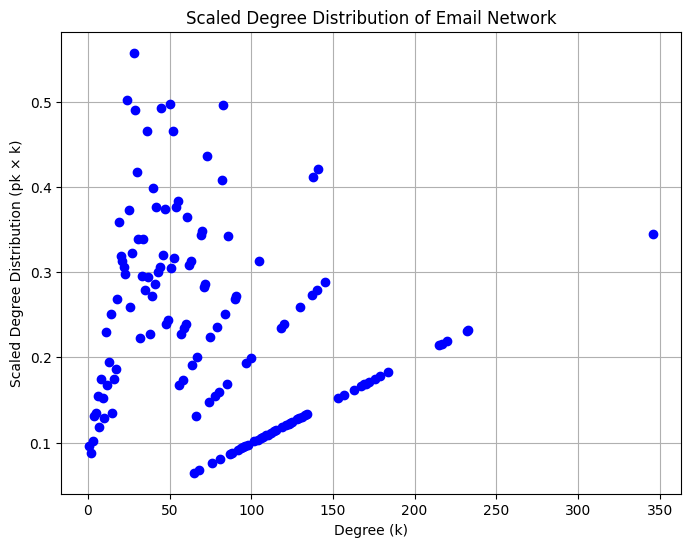

In [34]:
import sys
!{sys.executable} -m pip install matplotlib
import matplotlib.pyplot as plt

def plot_pk_scatter(ks, pkk):
    
    plt.figure(figsize=(8, 6))
    plt.plot(ks, pkk, 'bo')

    plt.xlabel("Degree (k)")
    plt.ylabel("Scaled Degree Distribution (pk × k)")
    plt.title("Scaled Degree Distribution of Email Network")
    plt.grid(True)

    plt.savefig("scaled_degree_distribution.png")
    plt.show()



plot_pk_scatter(k_values, pk_scaled)


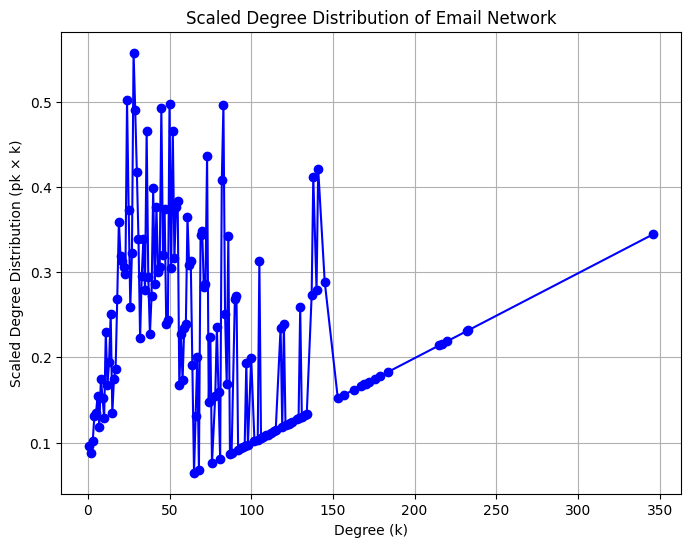

In [35]:
def plot_pk_line(ks, pkk):
    plt.figure(figsize=(8, 6))
    
    plt.plot(ks, pkk, marker='o', linestyle='-', color='blue')
    plt.xlabel("Degree (k)")
    plt.ylabel("Scaled Degree Distribution (pk × k)")

    plt.title("Scaled Degree Distribution of Email Network")
    plt.grid(True)
    plt.savefig("scaled_degree_distribution.png")
    plt.show()


plot_pk_line(k_values, pk_scaled)


### Observation

The scaled degree distribution shows a right-skewed pattern.
Most nodes have small degree, while few nodes have high degree.
This indicates heterogeneity in connectivity.


# Q2 – Directed Graph Analysis






In this question, we compute:
1. In-degree of each node
2. Out-degree of each node
3. In-degree distribution
4. Out-degree distribution

The implementation is done from scratch without using any graph libraries.


Here we extend the same dataset but now we respect direction. That small change actually matters a lot. Instead of just “degree”, we now compute in-degree and out-degree separately. A node with high out-degree probably sends many emails (active sender), while a node with high in-degree likely receives many (popular or important person).

When plotting the degree distributions 
P(k) for both in and out, we notice they are not symmetric. Most nodes have small degree, and only a few have very large values ; which gives that heavy-tailed shape. This is typical for communication networks.

Putting both distributions on the same plot helps compare them better and clearly shows the network is heterogeneous and not random at all.

## Dataset Description

We use the Email-Eu-core network from SNAP.

- Type: Directed graph
- Nodes represent email accounts
- Edges represent email communication from sender → receiver
- Total Nodes (N): Computed from dataset
- Total Edges (L): Computed from dataset


In [36]:
# !wget https://snap.stanford.edu/data/email-Eu-core.txt.gz
# !gunzip email-Eu-core.txt.gz
# Commented out the above lines as the dataset is already downloaded and extracted. at Ques 1

In [37]:
import os
os.listdir()


['email-Eu-core.txt',
 '2022496_2022498.ipynb',
 '2022496_2022498.ipynb - Colab.pdf',
 'scaled_degree_distribution.png']

In [38]:
def load_dir_edges(path):
    edges=[]
    with open(path,   "r") as f:
        for ln in f:
            if ln.startswith("#"):
                
                continue
            u,   v=ln.strip().split()
            edges.append((int(u),   int(v)))
    return edges


def get_nodes(edges):
    nodes=set()
    for u,  v in edges:
        nodes.add(u)
        nodes.add(v)
    return nodes



edge_list=load_dir_edges("email-Eu-core.txt")
node_set=get_nodes(edge_list)
num_nodes=len(node_set)


print("Total Nodes:",  num_nodes)
print("Total Edges:",   len(edge_list))


Total Nodes: 1005
Total Edges: 25571


In [39]:
def in_out_deg(nodes, edges):
    indeg={n: 0 for n in nodes}
    outdeg  ={n: 0 for n in  nodes}
    # worng code:
    # without indeg and outdeg initialization, we would get KeyError when we try to update counts for nodes that haven't been seen before. --- IGNORE ---

    for u, v in edges: # for each directed edge u->v
        outdeg[u] +=1
        indeg[v] +=1

    return indeg,outdeg # done


in_degree,out_degree =in_out_deg(node_set, edge_list) # done
print("Sample In-Degree:",   list(in_degree.items())[:5]) # print a Sample of in-degree Cpunts for the first 5Nodes
print("Sample Out-Degree:",  list(out_degree.items())[:5]) # print a saMple of out-degree counts for the first 5 nodes


Sample In-Degree: [(0, 32), (1, 51), (2, 77), (3, 62), (4, 74)]
Sample Out-Degree: [(0, 41), (1, 1), (2, 84), (3, 56), (4, 89)]


## Step 2: Degree Distribution

Degree distribution P(k):

P(k) = Number of nodes with degree k / Total number of nodes


In [40]:
from collections import Counter

def norm_dist(deg_map,n):
    vals=list(deg_map.values())
    
    cnt=Counter(vals)
    ks=sorted(cnt.keys())
    pk=[cnt[k] / n for k in ks]
    return ks,pk


in_k,in_pk=norm_dist(in_degree,num_nodes)
out_k,out_pk=norm_dist(out_degree,num_nodes)


## Step 3: Plotting In-Degree and Out-Degree Distribution

The distributions are plotted and saved as PNG as required.


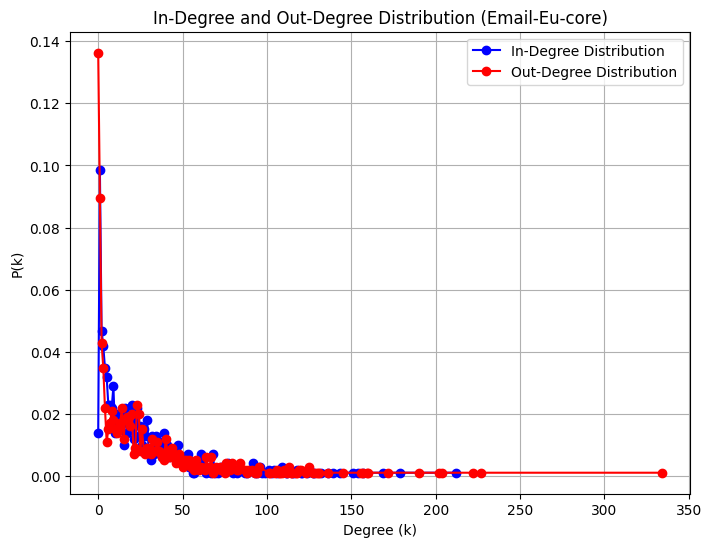

In [41]:
import matplotlib.pyplot as plt

def plot_in_out(in_k,in_pk,out_k,out_pk):
    plt.figure(figsize=(8,6))
    
    plt.plot(in_k,in_pk,'bo-',label="In-Degree Distribution")
    plt.plot(out_k,out_pk,'ro-',label="Out-Degree Distribution")
    plt.xlabel("Degree (k)")

    plt.ylabel("P(k)")
    plt.title("In-Degree and Out-Degree Distribution (Email-Eu-core)")
    plt.legend()

    plt.grid(True)
    plt.savefig("Q2_degree_distribution.png",dpi=300)
    plt.show()


plot_in_out(in_k,in_pk,out_k,out_pk)


# Q3: Weighted Network Analysis (Real-World Dataset)




## Dataset Used
US Airport Network (Weighted)
Nodes: Airports
Edges: Flight routes
Weight: Number of flights

This is a real-world weighted network with N > 200.

This question shifts to a weighted airport network, where edges represent number of flights. In this case, simple degree is not enough because it only counts connections, not traffic volume. That’s why strength (weighted degree) is more meaningful. Some airports may not have the highest number of connections but still handle huge traffic.

The weighted degree distribution is strongly skewed. Only a few airports dominate the total traffic, which reflects real-world airline structure.

We also compute the weighted clustering coefficient using Barrat’s formulation. This version considers edge weights when evaluating triangles, so it gives more realistic insight. An interesting pattern appears; clustering tends to decrease as degree increases. That suggests large hubs connect many different regions that are not necessarily connected to each other, while smaller airports form tighter local clusters.

In [42]:
import urllib.request
from collections import defaultdict

def load_routes(url):
    lines=urllib.request.urlopen(url).read().decode("utf-8").split("\n")
    adj=defaultdict(dict)


    for ln in lines:
        parts=ln.split(",")
        if len(parts) < 5:
            continue


        try:
            u=parts[3]
            v=parts[5]
            if u == "\\N" or v == "\\N":
                continue
            adj[u][v]=adj[u].get(v,0) + 1
            adj[v][u]=adj[v].get(u,0) + 1
        except Exception:
            continue

    return adj


routes_url="https://raw.githubusercontent.com/jpatokal/openflights/master/data/routes.dat"
adj=load_routes(routes_url)
print("Number of nodes:",len(adj))


Number of nodes: 3330


## Redefinition of Degree for Weighted Network

In a weighted network, the traditional notion of degree (number of neighbors)
is extended to include edge weights.

Weighted Degree (also called Strength):

s_i = sum of weights of all edges connected to node i

This captures the total intensity of connections instead of just counting edges.


In [43]:
def strength_map(adj):
    
    s={}
    for node in adj:
        tot=0

        for nbr in adj[node]:
            tot+=adj[node][nbr]
        s[node]=tot

    return s
strength=strength_map(adj)
print("Computed weighted degree (strength) for all nodes.")


Computed weighted degree (strength) for all nodes.


## Weighted Degree Distribution

We compute the probability distribution P(s), where:

P(s) = fraction of nodes having weighted degree s.


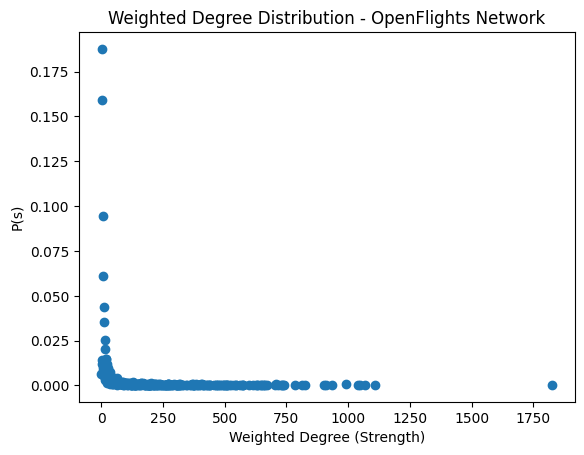

In [44]:
import matplotlib.pyplot as plt

def strength_dist(s_map):
    hist={}
    for s in s_map.values():
        hist[s]=hist.get(s,0) + 1

    n=len(s_map)
    dist={}
    for s in hist:
        dist[s]=hist[s] / n
    return dist


def plot_s_dist(dist):
    plt.figure()
    plt.scatter(dist.keys(),dist.values())
    plt.xlabel("Weighted Degree (Strength)")


    plt.ylabel("P(s)")
    plt.title("Weighted Degree Distribution - OpenFlights Network")

    
    plt.savefig("weighted_degree_distribution.png")
    plt.show()


s_dist=strength_dist(strength)
plot_s_dist(s_dist)


## Weighted Clustering Coefficient

For a weighted network, clustering coefficient must account for edge weights.

We use Barrat's formulation:

C_i^w = (1 / (s_i (k_i - 1))) *
        sum over neighbor pairs of ((w_ij + w_ih)/2)

Where:
- s_i = strength of node i
- k_i = degree of node i
- w_ij = weight between nodes i and j

This incorporates triangle intensity.


In [45]:
def w_cluster(node):
    nbrs=list(adj[node].keys())
    k=len(nbrs)

    if k < 2:
        return 0.0

    s_i=strength[node]
    tri=0



    for i in range(k):
        for j in range(i + 1, k):
            u=nbrs[i]

            
            v=nbrs[j]
            if v in adj[u]:


                w_iu=adj[node][u]
                w_iv=adj[node][v]
                tri += (w_iu + w_iv)/2

    return tri/(s_i * (k - 1))


In [46]:
def clust_deg_maps(adj):
    c_map,d_map={},{}
    for node in adj:
        c_map[node]=w_cluster(node)
        d_map[node]=len(adj[node])

        
    return c_map,d_map


clustering,degree=clust_deg_maps(adj)
print("Computed clustering coefficient for all nodes.")


Computed clustering coefficient for all nodes.


## Clustering Coefficient vs Degree

We now examine how clustering varies with node degree.
This helps understand structural hierarchy in the network.


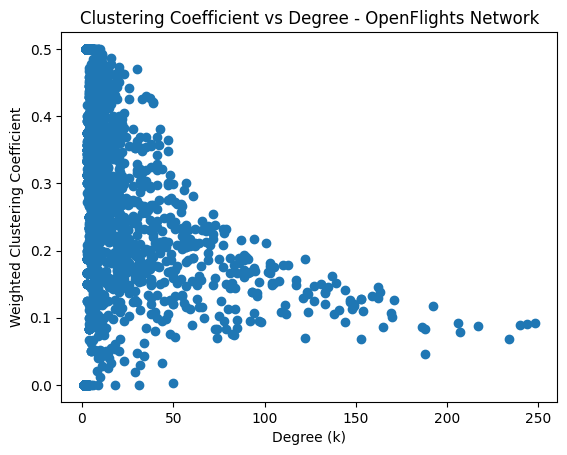

In [47]:
def kd_points(adj,d_map,c_map):
    k_vals,c_vals = [],[]
    for node in adj:
        k_vals.append(d_map[node])
        c_vals.append(c_map[node])
    return k_vals,c_vals


def plot_k_vs_c(k_vals,c_vals):
    plt.figure()
    plt.scatter(k_vals,c_vals)

    
    plt.xlabel("Degree (k)")
    plt.ylabel("Weighted Clustering Coefficient")
    plt.title("Clustering Coefficient vs Degree - OpenFlights Network")
    plt.savefig("clustering_vs_degree.png")
    plt.show()


deg_vals,clust_vals = kd_points(adj,degree,clustering)
plot_k_vs_c(deg_vals,clust_vals)


## Interpretation

1. The weighted degree distribution is highly heterogeneous.
2. A few airports act as hubs with very high strength.
3. Clustering coefficient generally decreases with increasing degree.
4. High-degree airports connect different regions globally.
5. Low-degree airports tend to form tightly connected local clusters.

This behavior is consistent with real-world transportation networks.


# Q4: Gilbert Random Graph Comparison



In this section, we generate a Gilbert random graph G(N, p) corresponding
to a real-world undirected and unweighted network.

We compare:
1. Degree distribution of the real network
2. Degree distribution of one random graph
3. Average degree distribution over 100 random graph instances


In this part, we compare the real social network with a Gilbert random graph 
G(N,p) built using the same 
L. At first glance they might seem comparable because they share size and density. But structurally they behave very differently.

Random graphs usually produce narrow, binomial or Poisson-like degree distributions. The real network instead shows a heavy-tailed distribution with strong heterogeneity.

Even when averaging over multiple random runs, the difference remains. So it’s not noise. This highlights why simple random graph models fail to capture properties like hubs, clustering, and community structure. It shows we need more realistic generative models.

## Import Required Libraries

As per assignment guidelines:
- Only standard libraries
- numpy only for arrays (not graph algorithms)


In [48]:
import os
import urllib.request
import gzip

import random
import collections

import numpy as np
import matplotlib.pyplot as plt


## Step 1: Load Real Network (Undirected & Unweighted)

We assume the network is stored as an edge list:
Each line contains: node1 node2


In [49]:
dataset_url="http://snap.stanford.edu/data/facebook_combined.txt.gz"
out_gz="facebook_combined.txt.gz"

out_txt="facebook_combined.txt"

print("Downloading dataset…")
urllib.request.urlretrieve(dataset_url,out_gz)


print("Download completed!")


Download completed!


In [50]:
def unzip_gz(src,dst):

    print("Unzipping…")
    with gzip.open(src,"rb") as f_in:


        with open(dst,"wb") as f_out:
            f_out.write(f_in.read())
    print("Unzip complete!")
    
    print("Files now in:",os.listdir())


unzip_gz(out_gz,out_txt)


Unzipping…
Unzip complete!
Files now in: ['email-Eu-core.txt', 'weighted_degree_distribution.png', '2022496_2022498.ipynb', 'Q2_degree_distribution.png', '2022496_2022498.ipynb - Colab.pdf', 'scaled_degree_distribution.png', 'facebook_combined.txt', 'facebook_combined.txt.gz', 'clustering_vs_degree.png']


In [51]:
def load_graph(path):
    edges,nodes=[],set()

    with open(path,'r') as f:
        for ln in f:
            u,v=ln.strip().split()
            nodes.add(u)


            nodes.add(v)
            edges.append((u,v))



    return list(nodes),edges


nodes,edges=load_graph(out_txt)
num_nodes=len(nodes)

num_edges=len(edges)

print("Loaded graph with:")


print("N =",num_nodes)
print("L =",num_edges)


Loaded graph with:
N = 4039
L = 88234


In [52]:
def gilbert_p(n, l):
    return (2 * l) / (n * (n - 1))


p=gilbert_p(num_nodes, num_edges)
print("Computed p:", p)



Computed p: 0.010819963503439287


In [53]:
def gen_gilbert(nodes, p):
    e=[]
    for i in range(len(nodes)):


        for j in range(i + 1, len(nodes)):
            if random.random() < p:

                
                e.append((nodes[i], nodes[j]))
    return e


In [54]:
def deg_dist(nodes, edges):
    deg=dict.fromkeys(nodes, 0)


    for u, v in edges:
        deg[u]+=1
        deg[v]+=1

    vals=list(deg.values())
    cnt=collections.Counter(vals)

    
    k=list(cnt.keys())
    pk=[cnt[i] / len(nodes) for i in k]

    return k, pk


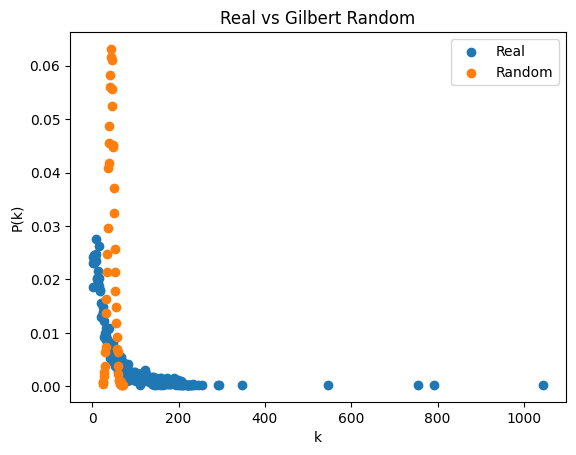

In [55]:
def plot_real_rand(nodes,edges,p):
    k_real,pk_real=deg_dist(nodes,edges)
    r_edges=gen_gilbert(nodes,p)
    k_rand,pk_rand=deg_dist(nodes,r_edges)

    plt.figure()


    plt.scatter(k_real,pk_real,label="Real")
    plt.scatter(k_rand,pk_rand,label="Random")


    plt.xlabel("k")
    plt.ylabel("P(k)")
    plt.title("Real vs Gilbert Random")
    plt.legend()
    
    plt.savefig("real_vs_random.png")
    plt.show()

    return k_real,pk_real,k_rand,pk_rand


k_real,pk_real,k_rand,pk_rand=plot_real_rand(nodes,edges,p)


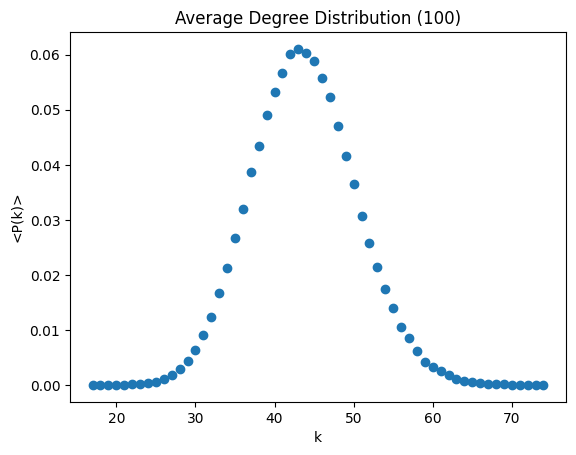

In [56]:
def avg_rand_dist(nodes,p,runs):
    acc={}



    for _ in range(runs):
        r_edges=gen_gilbert(nodes,p)


        k,pk=deg_dist(nodes,r_edges)
        for kk,vv in zip(k,pk):
            acc[kk]=acc.get(kk,0) + vv

    k_avg=sorted(acc.keys())
    pk_avg=[acc[kk] / runs for kk in k_avg]

    return k_avg,pk_avg


def plot_avg_dist(k_avg,pk_avg):
    plt.figure()
    plt.scatter(k_avg,pk_avg)

    
    plt.xlabel("k")
    plt.ylabel("<P(k)>")


    plt.title("Average Degree Distribution (100)")
    plt.savefig("avg_100.png")
    plt.show()







num_runs=100
k_avg,pk_avg=avg_rand_dist(nodes,p,num_runs)
plot_avg_dist(k_avg,pk_avg)


### Observations

1. The Facebook network shows a broad degree distribution (heavy tail).
2. The Gilbert model shows a narrower binomial/Poisson-like distribution.
3. The average over 100 repeats confirms the random model shape.
4. Real network deviates significantly from pure random connectivity.


# Q5: Breadth First Search (BFS) Implementation from Scratch




In this task, we implement the Breadth-First Search (BFS) algorithm
from scratch using adjacency lists.

The BFS function returns:
- Distance of every node from the source
- Parent of each node in the BFS tree
- Nodes grouped by BFS layers

No recursion and no external graph libraries are used.

For the final question, we implement BFS from scratch without using any external graph libraries. The function returns distances from a source node, parent pointers, and nodes grouped by layers.

BFS is not just for shortest paths in unweighted graphs; it also reveals how the network expands outward from the source. Keeping track of parents builds a BFS tree, which can later be used to reconstruct paths.

Grouping nodes by layers makes the traversal easier to visualize. It shows how quickly the network spreads and where bottlenecks or peripheral nodes appear. It gives a more intuitive sense of connectivity structure.

In [57]:
# Small undirected test graph using adjacency list
# Graph structure:
#
#       A
#      / \
#     B   C
#    / \   \
#   D   E   F
#        \
#         G

graph = {
    'A': ['B','C'],
    'B': ['A','D','E'],
    'C': ['A','F'],
    'D': ['B'],
    'E': ['B','G'],
    'F': ['C'],
    'G': ['E']
}





def show_adj(g):
    print("Adjacency List Representation:")
    for node in g:
        print(node,":",g[node])


show_adj(graph)


Adjacency List Representation:
A : ['B', 'C']
B : ['A', 'D', 'E']
C : ['A', 'F']
D : ['B']
E : ['B', 'G']
F : ['C']
G : ['E']


In [58]:
from collections import deque



def bfs(graph,src):
    vis=set()
    dist={}
    par={}
    layers={}
    q=deque()

    vis.add(src)
    dist[src]=0
    par[src]=None
    q.append(src)




    while q:
        cur=q.popleft()
        for nbr in graph[cur]:
            if nbr not in vis:
                vis.add(nbr)
                dist[nbr]=dist[cur] + 1
                par[nbr]=cur
                q.append(nbr)

    for node,d in dist.items():
        if d not in layers:
            layers[d]=[]
        layers[d].append(node)

    return dist,par,layers


In [59]:
source_node = 'A'

distance_map,parent_map,layer_map = bfs(graph,source_node)
print("Distance from source:")
for node in distance_map:
    print(f"{node}:{distance_map[node]}")
print("\nParent in BFS Tree:")
for node in parent_map:
    print(f"{node}:{parent_map[node]}")





print("\nBFS Layers:")
for layer in sorted(layer_map):
    print(f"Layer {layer}:{layer_map[layer]}")


Distance from source:
A:0
B:1
C:1
D:2
E:2
F:2
G:3

Parent in BFS Tree:
A:None
B:A
C:A
D:B
E:B
F:C
G:E

BFS Layers:
Layer 0:['A']
Layer 1:['B', 'C']
Layer 2:['D', 'E', 'F']
Layer 3:['G']


### BFS Results Interpretation

- Distance dictionary shows the shortest path length
  from source node 'A' to every other node.

- Parent dictionary represents the BFS tree.

- Layers group nodes according to their distance
  from the source:
  
  Layer 0 → Source node  
  Layer 1 → Immediate neighbors  
  Layer 2 → Nodes at distance 2  
  and so on.


### Complexity Analysis

Let:
V = number of vertices
E = number of edges

Time Complexity:
O(V + E)

Each node is visited once and each edge is explored once.

Space Complexity:
O(V)

Used for:
- visited set
- distance dictionary
- parent dictionary
- queue
